# Multi-Scale STEM Acquisition with ML Atom Finding

Acquire a moderate-magnification HAADF overview, select a region of interest,
zoom to atomic resolution at reduced dose, and locate atomic columns using a
convolutional neural network trained on matched synthetic data.

Tested with the digital twin (no hardware required).


### Start the servers

Launch the digital twin from the repository root:

```bash
uv run python startup_scripts/run_servers.py --yaml configs/DigitalTwin.yaml
```

Wait for **"All asyncroscopy servers are ready"** before running the cells below.


### Imports


In [1]:
import os
import json

import ase
import ase.visualize.plot
import tango
import torch
import numpy as np
import matplotlib.pyplot as plt
from tiled.client import from_uri
from scipy.ndimage import label, center_of_mass


### Connect to devices


In [ ]:
# --- Set the Tango database host ---
DB_HOST = "10.46.217.241"   # server IP
DB_PORT = 9094
# --------------------------------------------------------

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
scan = tango.DeviceProxy("asyncroscopy/scan/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for name, proxy in [("microscope", microscope), ("scan", scan), ("data", data)]:
    proxy.set_timeout_millis(30_000)
    print(f"{name:>12}: {proxy.state()}")


  microscope: ON
        scan: ON
        data: ON


In [ ]:
# Verify the column is ready for acquisition
print("Vacuum:", microscope.get_vacuum_state())

microscope.set_column_valves("open")
microscope.unblank_beam()

print("Column valves opened, beam unblanked")
print("Microscope parameters:")
from pprint import pprint
pprint(json.loads(microscope.get_parameters()))

### Tiled client


In [3]:
config = json.loads(data.get_config())
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))


Tiled keys: ['stem_image_HAADF_20260820T124221300618.h5', 'stem_image_HAADF_20260820T124256131118.h5', 'stem_image_HAADF_20260820T132925413652.h5', 'stem_image_HAADF_20260820T132927995394.h5', 'stem_image_HAADF_20260820T134425986702.h5']


## 1. Overview acquisition

Set the field of view to a scale where atomic columns begin to be resolvable.


In [4]:
# --- acquisition parameters ---
overview_fov_m: float = 50e-9
overview_dwell_s: float = 2e-6
overview_pixels: int = 512
# ------------------------------

microscope.set_fov(overview_fov_m)
scan.dwell_time = overview_dwell_s
scan.imsize = overview_pixels
scan.scan_region = [0.0, 0.0, 1.0, 1.0]

overview_key: str = microscope.acquire_scanned_image(["haadf"])

print(f"Key   : {overview_key}")
print(f"FOV   : {overview_fov_m * 1e9:.0f} nm")
print(f"Dwell : {overview_dwell_s * 1e6:.1f} µs")


Key   : stem_image_HAADF_20260820T141501248993.h5
FOV   : 50 nm
Dwell : 2.0 µs


Shape: (512, 512)  dtype: float32


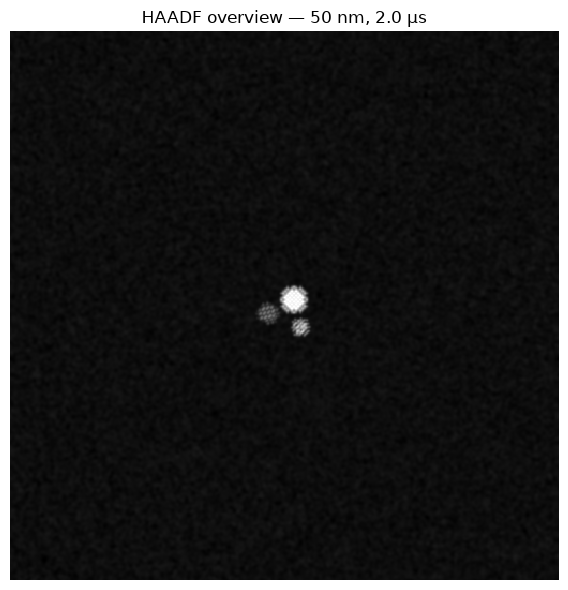

In [5]:
overview_node = client[overview_key]["image"]["HAADF"]
overview: np.ndarray = np.squeeze(overview_node.read())

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(overview, cmap="gray", interpolation="none")
ax.set_title(f"HAADF overview — {overview_fov_m * 1e9:.0f} nm, {overview_dwell_s * 1e6:.1f} µs")
ax.axis("off")
plt.tight_layout()

print(f"Shape: {overview.shape}  dtype: {overview.dtype}")


## 2. Select a region of interest

Define a sub-region of the overview to image at higher magnification.
Coordinates are fractional (0–1) relative to the current field of view.


Scan region: [0.375, 0.375, 0.625, 0.625]


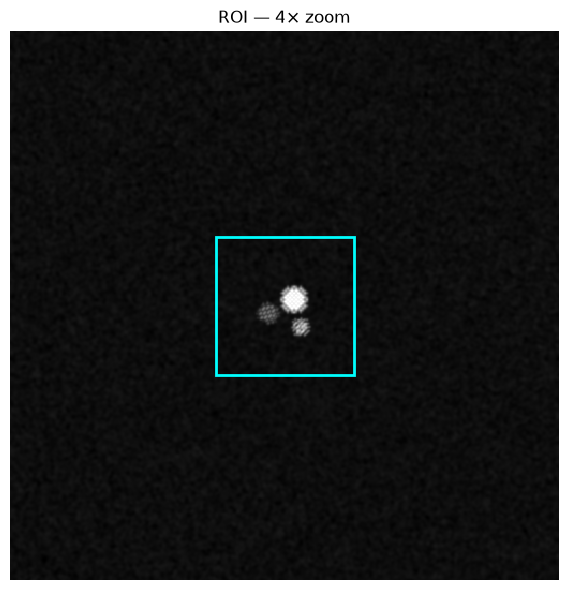

In [6]:
# --- ROI definition ---
roi_cx: float = 0.5
roi_cy: float = 0.5
zoom_factor: int = 4
# ----------------------

roi_half: float = 0.5 / zoom_factor
roi: list[float] = [
    max(0.0, roi_cx - roi_half),
    max(0.0, roi_cy - roi_half),
    min(1.0, roi_cx + roi_half),
    min(1.0, roi_cy + roi_half),
]

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(overview, cmap="gray", interpolation="none")
rect = plt.Rectangle(
    (roi[0] * overview.shape[1], roi[1] * overview.shape[0]),
    (roi[2] - roi[0]) * overview.shape[1],
    (roi[3] - roi[1]) * overview.shape[0],
    edgecolor="cyan", facecolor="none", linewidth=2,
)
ax.add_patch(rect)
ax.set_title(f"ROI — {zoom_factor}× zoom")
ax.axis("off")
plt.tight_layout()

print(f"Scan region: {roi}")


## 3. High-resolution acquisition at reduced dose

Reduce the FOV to zoom optically, then acquire at lower dwell time
to minimise beam damage at the cost of increased shot noise.


In [7]:
# --- high-resolution parameters ---
highres_dwell_s: float = 0.5e-6
highres_pixels: int = 512
# ----------------------------------

effective_fov_m: float = overview_fov_m / zoom_factor
microscope.set_fov(effective_fov_m)
scan.dwell_time = highres_dwell_s
scan.imsize = highres_pixels
scan.scan_region = [0.0, 0.0, 1.0, 1.0]

highres_key: str = microscope.acquire_scanned_image(["haadf"])

print(f"Key           : {highres_key}")
print(f"Effective FOV : {effective_fov_m * 1e9:.1f} nm")
print(f"Dwell         : {highres_dwell_s * 1e6:.1f} µs")


Key           : stem_image_HAADF_20260820T141520196793.h5
Effective FOV : 12.5 nm
Dwell         : 0.5 µs


Shape: (512, 512)  dtype: float32


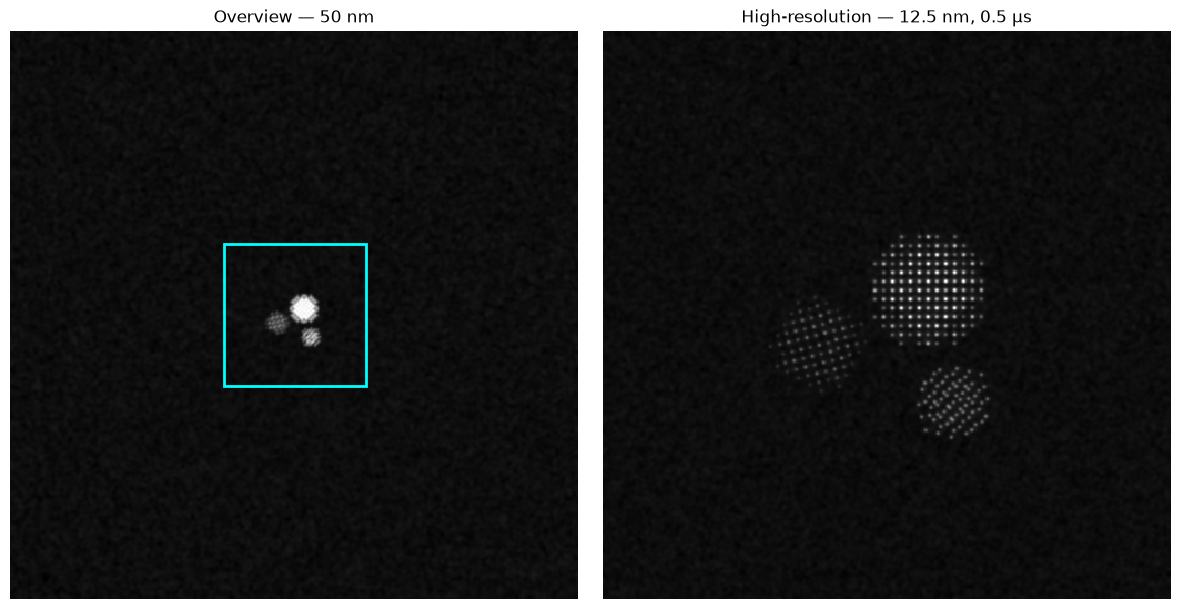

In [8]:
highres_node = client[highres_key]["image"]["HAADF"]
highres: np.ndarray = np.squeeze(highres_node.read())

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(overview, cmap="gray", interpolation="none")
rect = plt.Rectangle(
    (roi[0] * overview.shape[1], roi[1] * overview.shape[0]),
    (roi[2] - roi[0]) * overview.shape[1],
    (roi[3] - roi[1]) * overview.shape[0],
    edgecolor="cyan", facecolor="none", linewidth=2,
)
axes[0].add_patch(rect)
axes[0].set_title(f"Overview — {overview_fov_m * 1e9:.0f} nm")
axes[0].axis("off")

axes[1].imshow(highres, cmap="gray", interpolation="none")
axes[1].set_title(f"High-resolution — {effective_fov_m * 1e9:.1f} nm, {highres_dwell_s * 1e6:.1f} µs")
axes[1].axis("off")

plt.tight_layout()
print(f"Shape: {highres.shape}  dtype: {highres.dtype}")


## 4. Define crystal structure

Silicon diamond cubic unit cell built with ASE. This is the structure
used to generate synthetic training data for the atom-finding network.


Structure matrix:
 [[5.43 0.   0.  ]
 [0.   5.43 0.  ]
 [0.   0.   5.43]]
Atoms per cell: 8


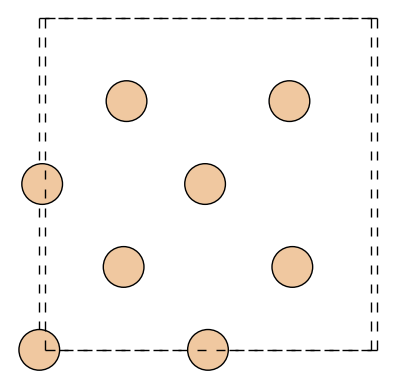

In [9]:
# Silicon diamond unit cell
a = 5.43  # Angstrom

structure_matrix = np.array([[a, 0.0, 0.0],
                             [0.0, a, 0.0],
                             [0.0, 0.0, a]])

elements = ['Si'] * 8
base = [[0, 0, 0], [1/2, 1/2, 0], [1/2, 0, 1/2], [0, 1/2, 1/2],
        [1/4, 1/4, 1/4], [3/4, 3/4, 1/4], [3/4, 1/4, 3/4], [1/4, 3/4, 3/4]]

crystal = ase.Atoms(elements, cell=structure_matrix, scaled_positions=base)

print('Structure matrix:\n', np.round(structure_matrix, 3))
print(f'Atoms per cell: {len(crystal)}')
ase.visualize.plot.plot_atoms(crystal, radii=0.3, rotation=('0x,1y,0z'));


## 5. Simulate HAADF images

Project the crystal along the beam direction, add thermal vibration (wobble),
render Gaussian peaks at each column position, and apply Poisson noise
based on electron counts.


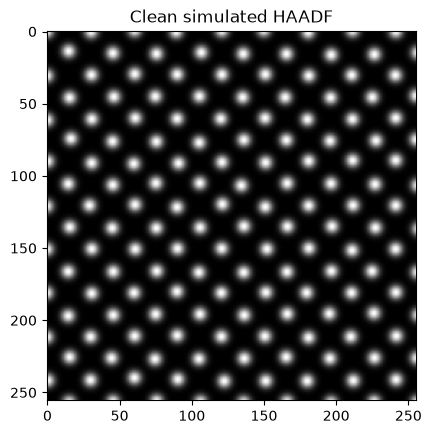

In [10]:
# ------Input ----------
pixel_size = 0.3    # Angstrom
supercell_number = 15
sigma = 1           # Angstrom
wobble = 0.05       # Angstrom
# ----------------------

def get_image(atoms, size=256, pixel_size=0.3, sigma=1, wobble=0.05):
    """Project atom positions along [001] and render as Gaussian peaks."""
    image = np.zeros([size, size])
    coords = np.arange(0, size) * pixel_size
    xx, yy = np.meshgrid(coords, coords)
    positions = np.unique(atoms.get_positions()[:, :2], axis=0) / pixel_size
    rim_max = (size + 3) * pixel_size
    rim_min = -2 * pixel_size
    atom_positions = []
    for (x, y) in positions:
        dx, dy = np.random.normal(0, wobble, 2) / pixel_size
        xdx = x + dx
        ydy = y + dy
        if rim_min < x < rim_max and rim_min < y < rim_max:
            image += np.exp(-(((xx - xdx) ** 2 + (yy - ydy) ** 2) / (2 * sigma ** 2)))
            atom_positions.append([xdx, ydy])
    return image, np.array(atom_positions) / pixel_size

image, atom_positions = get_image(crystal * supercell_number, size=256,
                                  pixel_size=pixel_size, sigma=sigma, wobble=wobble)
plt.figure()
plt.imshow(image, cmap='gray')
plt.title('Clean simulated HAADF')
plt.show()


In [27]:
# ------Input ----------
counts = 30000
# ----------------------

def poisson_noise(image: np.ndarray, counts: float) -> np.ndarray:
    """Apply normalised Poisson noise based on simulated electron counts."""
    image = image - image.min()
    total = float(image.sum())
    if total <= 0 or counts <= 0:
        return np.zeros_like(image, dtype=np.float32)
    image = image / total
    noisy = np.random.poisson(image * counts).astype(np.float32)
    noisy -= noisy.min()
    m = float(noisy.max())
    if m > 0:
        noisy /= m
    return noisy


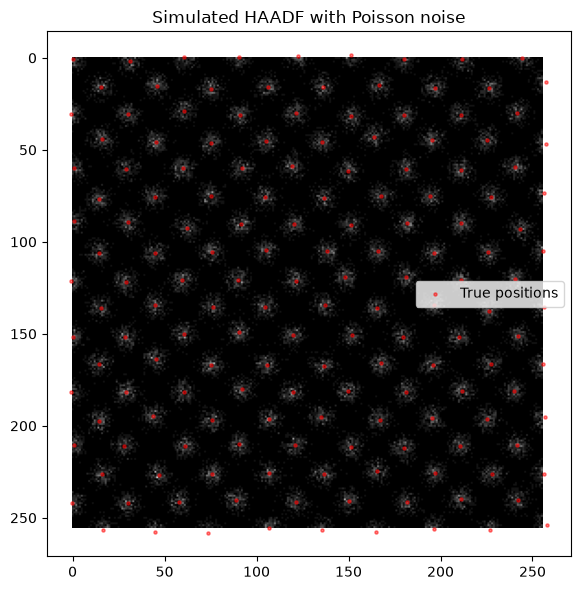

In [28]:
def simulate_haadf(atoms, size=256, wobble=0.08, counts=200000, sigma=1):
    """Create a simulated HAADF image from an ASE crystal structure."""
    image, atom_positions = get_image(atoms, wobble=wobble, sigma=sigma)
    noisy_image = poisson_noise(image, counts)
    return image, noisy_image, atom_positions

_, image, true_atoms = simulate_haadf(crystal * supercell_number, counts=counts)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(image, cmap='gray')
ax.scatter(true_atoms[:, 0], true_atoms[:, 1], c='red', s=5, alpha=0.5, label='True positions')
ax.legend()
ax.set_title('Simulated HAADF with Poisson noise')
plt.tight_layout()
plt.show()


## 6. Build and train the U-Net


In [29]:
class TinyUNet(torch.nn.Module):
    """A minimal U-Net for atom segmentation."""

    def __init__(self):
        super().__init__()
        self.enc1 = self._block(1, 16)
        self.enc2 = self._block(16, 32)
        self.pool = torch.nn.MaxPool2d(2)
        self.bottleneck = self._block(32, 64)
        self.up2 = torch.nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self._block(64, 32)
        self.up1 = torch.nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = self._block(32, 16)
        self.out = torch.nn.Conv2d(16, 1, kernel_size=1)

    def _block(self, in_ch, out_ch):
        return torch.nn.Sequential(
            torch.nn.Conv2d(in_ch, out_ch, 3, padding=1),
            torch.nn.BatchNorm2d(out_ch),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(out_ch, out_ch, 3, padding=1),
            torch.nn.BatchNorm2d(out_ch),
            torch.nn.ReLU(inplace=True),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.sigmoid(self.out(d1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TinyUNet().to(device)
print(f"Device: {device}  Parameters: {sum(p.numel() for p in model.parameters()):,}")


Device: cpu  Parameters: 117,393


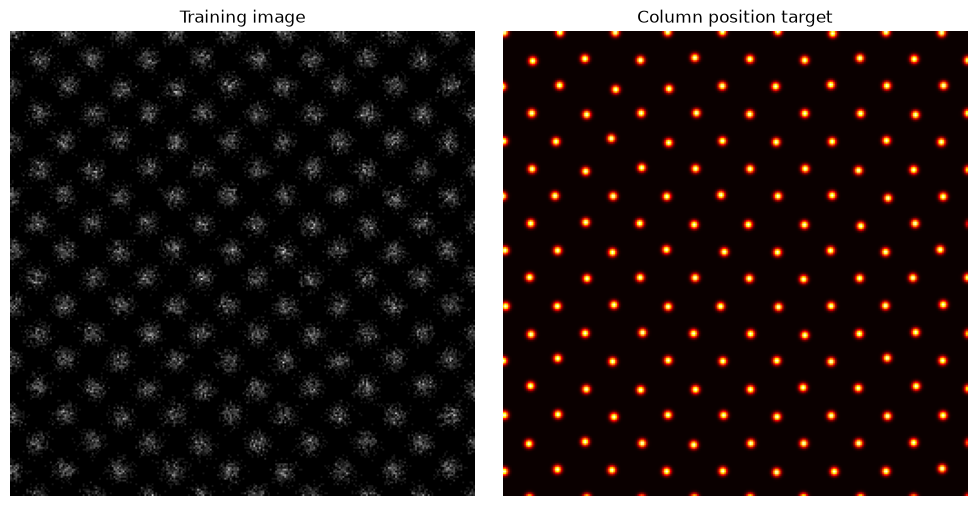

Training set: 40 images, counts = 30000


In [31]:
def make_label_mask(atoms, size=256, sigma=1.5):
    """Create a target mask with Gaussian peaks at each column position."""
    mask = np.zeros((size, size), dtype=np.float32)
    for ax, ay in atoms:
        yy, xx = np.mgrid[0:size, 0:size]
        mask += np.exp(-((xx - ax)**2 + (yy - ay)**2) / (2 * sigma**2))
    return np.clip(mask, 0, 1)

# ------Input ----------
n_train = 40
# ----------------------

train_images = []
train_labels = []

for i in range(n_train):
    _, img, atom_positions = simulate_haadf(crystal * supercell_number,
                                             counts=counts, wobble=wobble, sigma=sigma)
    lbl = make_label_mask(atom_positions, size=256, sigma=1.5)
    train_images.append(img)
    train_labels.append(lbl)

train_images = np.array(train_images)
train_labels = np.array(train_labels)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(train_images[0], cmap='gray')
axes[0].set_title('Training image')
axes[1].imshow(train_labels[0], cmap='hot')
axes[1].set_title('Column position target')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Training set: {n_train} images, counts = {counts}")


Epoch  10/100  loss = 0.5095
Epoch  20/100  loss = 0.4526
Epoch  30/100  loss = 0.4133
Epoch  40/100  loss = 0.3844
Epoch  50/100  loss = 0.3605
Epoch  60/100  loss = 0.3389
Epoch  70/100  loss = 0.3187
Epoch  80/100  loss = 0.2997
Epoch  90/100  loss = 0.2818
Epoch 100/100  loss = 0.2653


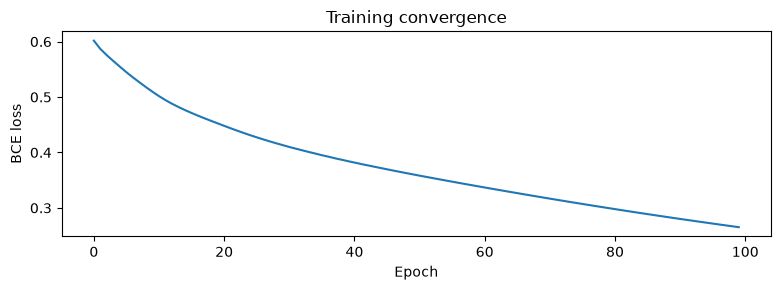

In [32]:
# -------- Input ----------
epochs = 100
# -------------------------

X_train = torch.tensor(train_images[:, None, :, :])
y_train = torch.tensor(train_labels[:, None, :, :])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.BCELoss()
losses = []

for epoch in range(epochs):
    model.train()
    inputs = X_train.to(device)
    targets = y_train.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1:>3}/{epochs}  loss = {loss.item():.4f}")

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('BCE loss')
plt.title('Training convergence')
plt.tight_layout()


## 7. Atom finding on the experimental image

Apply the trained network to the high-resolution HAADF acquisition.
Connected-component labelling on the thresholded probability map
yields sub-pixel column positions via centre-of-mass extraction.


In [33]:
def predict_tiled(model, image, tile_size=256, overlap=32, device='cpu'):
    """Apply the network to an arbitrarily sized image by tiling."""
    h, w = image.shape
    if h <= tile_size and w <= tile_size:
        inp = torch.tensor(image[None, None, :, :], dtype=torch.float32).to(device)
        with torch.no_grad():
            return model(inp).cpu().numpy()[0, 0]

    step = tile_size - overlap
    heatmap = np.zeros((h, w), dtype=np.float32)
    counts_map = np.zeros((h, w), dtype=np.float32)

    model.eval()
    with torch.no_grad():
        for y0 in range(0, h - tile_size + 1, step):
            for x0 in range(0, w - tile_size + 1, step):
                patch = image[y0:y0 + tile_size, x0:x0 + tile_size]
                inp = torch.tensor(patch[None, None, :, :], dtype=torch.float32).to(device)
                out = model(inp).cpu().numpy()[0, 0]
                heatmap[y0:y0 + tile_size, x0:x0 + tile_size] += out
                counts_map[y0:y0 + tile_size, x0:x0 + tile_size] += 1.0

    return heatmap / np.maximum(counts_map, 1.0)

# Normalise experimental image
hr = highres.astype(np.float32)
lo, hi = np.percentile(hr, [1, 99.5])
hr_norm = np.clip((hr - lo) / (hi - lo + 1e-8), 0, 1)

model.eval()
heatmap = predict_tiled(model, hr_norm, device=device)
print(f"Probability map: {heatmap.shape}  range [{heatmap.min():.3f}, {heatmap.max():.3f}]")


Probability map: (512, 512)  range [0.000, 0.698]


Detected 190 atomic columns


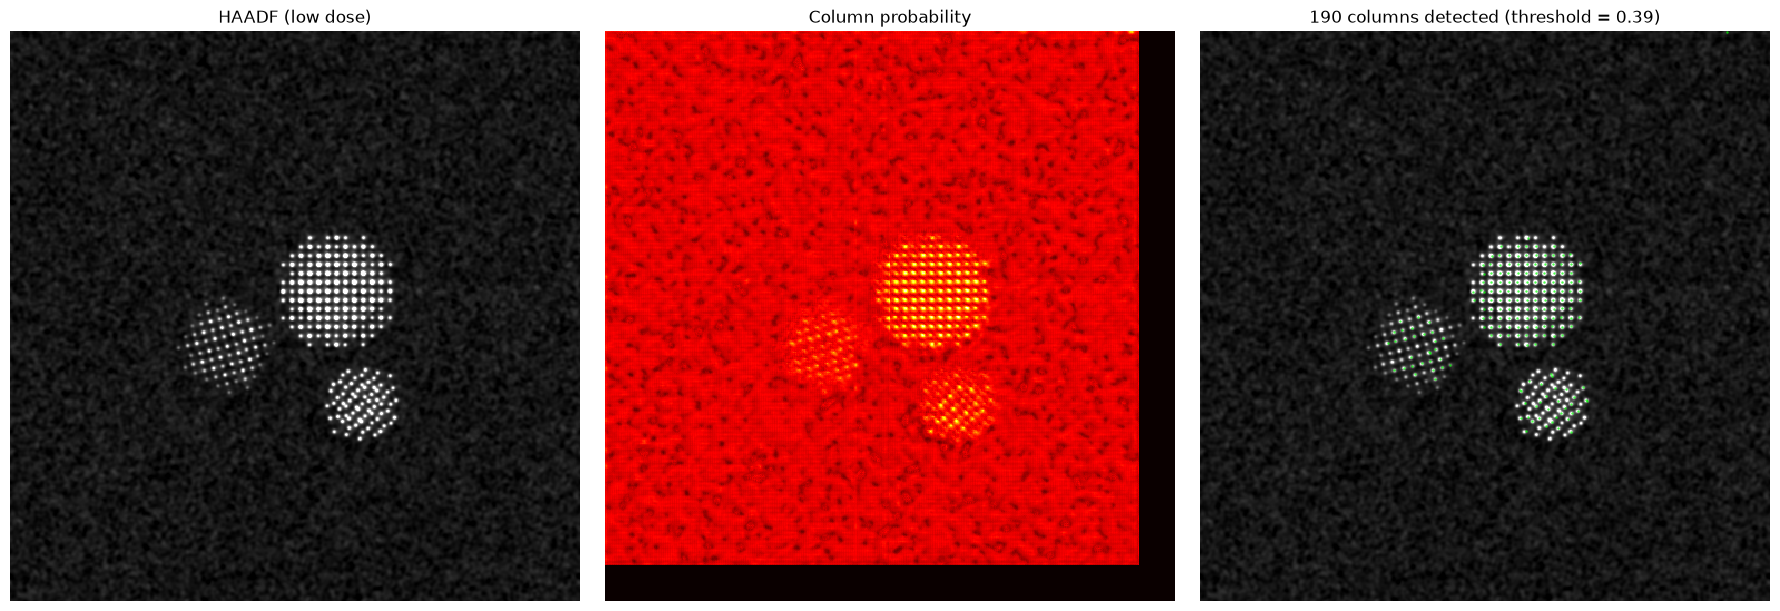

In [34]:
# --- detection threshold ---
threshold: float = 0.39
# --------------------------

binary = heatmap > threshold
labelled, n_atoms = label(binary)
positions = np.array(center_of_mass(binary, labelled, range(1, n_atoms + 1)))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(hr_norm, cmap="gray", interpolation="none")
axes[0].set_title("HAADF (low dose)")
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="hot", interpolation="none")
axes[1].set_title("Column probability")
axes[1].axis("off")

axes[2].imshow(hr_norm, cmap="gray", interpolation="none")
if len(positions) > 0:
    axes[2].scatter(positions[:, 1], positions[:, 0], c="lime", s=3, alpha=0.7, linewidths=0)
axes[2].set_title(f"{n_atoms} columns detected (threshold = {threshold})")
axes[2].axis("off")

plt.tight_layout()
print(f"Detected {n_atoms} atomic columns")


## 8. Parameter reference

| Parameter | Location | Effect |
|---|---|---|
| `overview_fov_m` | §1 | Survey field of view [m] |
| `overview_dwell_s` | §1 | Dwell time for the survey [s/px] |
| `roi_cx`, `roi_cy` | §2 | ROI centre in fractional coordinates |
| `zoom_factor` | §2 | Magnification increase for the high-res scan |
| `highres_dwell_s` | §3 | Reduced dwell time for low-dose imaging [s/px] |
| `pixel_size` | §5 | Simulation pixel size [Å] |
| `supercell_number` | §5 | Number of unit cell repeats |
| `sigma` | §5 | Column peak width [Å] |
| `wobble` | §5 | Thermal displacement amplitude [Å] |
| `counts` | §5 | Electron counts for Poisson noise |
| `n_train` | §6 | Number of synthetic training images |
| `epochs` | §6 | Training iterations |
| `threshold` | §7 | Probability cutoff for column detection |
